In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_iris
from sklearn.ensemble import RandomForestClassifier as SklearnRF
from sklearn.metrics import accuracy_score

## Problem with a single Decision Tree: overfits easily.
## Solution: build MANY trees and let them vote.

## Random Forest = Bagging + Feature Randomness

## Bagging (Bootstrap Aggregating):
   1. Create N random samples of the training data (with replacement)
   2. Train a Decision Tree on each sample
   3. For prediction, each tree votes, majority wins

# Feature Randomness:
    1. At each split, only consider a random subset of features.
    2. This decorrelates the trees (makes them different from each other).
    3. Typical: sqrt(n_features) features per split.

# Why it works:
1. Individual trees are weak and noisy.
2. But their errors are random and uncorrelated.
3. Averaging many uncorrelated errors reduces total error.
4. This is the "wisdom of crowds" in ML.


#### Random Forest = Many Decision Trees + Voting


In [29]:
class SimpleDecisionTree:

    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples = min_samples_split
        self.max_f = max_features
        self.root = None

    def _gini(self, y):
        if len(y) == 0:
            return 0 

        proportions = np.bincount(y) / len(y)
        return 1 - np.sum(proportions ** 2)

    def _best_split(self, X, y):
        best_gain = -1 
        best_feature = None 
        best_threshold = None 
        n_features = X.shape[1]

        if self.max_f:
            feature_indx = np.random.choice(n_features, self.max_f, replace=False)
        else:
            feature_indx = range(n_features)

        parent_gini = self._gini(y)

        for feature in feature_indx:
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                n = len(y)
                child_gini = (np.sum(left_mask) / n * self._gini(y[left_mask])) + \
                              (np.sum(right_mask) / n * self._gini(y[right_mask]))
                
                gain = parent_gini - child_gini
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold 

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, depth=0):
        n_classes = len(np.unique(y))
        if depth >= self.max_depth or n_classes == 1 or len(y) < self.min_samples:
            return {'leaf': True, 'value': np.argmax(np.bincount(y))}

        feature, threshold, gain = self._best_split(X, y)
        if gain is None or gain <= 0:
            return  {'leaf': True, 'value': np.argmax(np.bincount(y))}

        left_mask = X[:, feature] <= threshold
        return {
            'leaf': False,
            'feature': feature,
            'threshold': threshold,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        }

    def fit(self, X, y):
        self.root = self._build_tree(X, y)
        return self

    def _traverse(self, x, node):
        if node['leaf']:
            return node['value']
        if x[node['feature']] <= node['threshold']:
            return self._traverse(x, node['left'])
        return self._traverse(x, node['right'])

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])
                    
        

In [30]:
print("SimpleDecisionTree class defined (with max_features for randomness)")

SimpleDecisionTree class defined (with max_features for randomness)


In [31]:
class RandomForestScratch:

    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, max_features='sqrt'):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples = min_samples_split
        self.max_ff = max_features
        self.trees = []

    def _boostrap_sample(self, X, y):
        n_samples = X.shape[0]
        indx = np.random.choice(n_samples, n_samples, replace=True)
        return X[indx], y[indx]

    def fit(self, X, y):
        self.trees = []
        n_features = X.shape[1]

        if self.max_ff == 'sqrt':
            max_feat = int(np.sqrt(n_features))
        elif self.max_ff == 'log2':
            max_feat = int(np.log2(n_features))
        else:
            max_feat = self.max_ff

        for i in range(self.n_trees):
            X_boot, y_boot = self._boostrap_sample(X, y) 
            tree = SimpleDecisionTree(
                max_depth=self.max_depth, 
                min_samples_split=self.min_samples,
                max_features=max_feat
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

        return self

    def predict(self, X):
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])

        predictions = np.array([
            np.argmax(np.bincount(tree_predictions[:, i]))
            for i in range(X.shape[0])
        ])

        return predictions

    def score(self, X, y):
        return np.mean(self.predict(X) == y)
        

In [32]:
print("RandomForestScratch class defined")
print(f"Methods: fit(), predict(), score()")

RandomForestScratch class defined
Methods: fit(), predict(), score()


In [33]:
np.random.seed(42)

X, y = make_classification(
    n_samples=500, n_features=10, n_redundant=2,
    n_informative=8, n_clusters_per_class=1,
    random_state =42
)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

sg_tre = SimpleDecisionTree(max_depth=5)
sg_tre.fit(X_train, y_train)
sg_acc = np.mean(sg_tre.predict(X_test) == y_test) * 100

forest = RandomForestScratch(n_trees=50, max_depth=5)
forest.fit(X_train, y_train)
forest_acc = forest.score(X_test, y_test) * 100

print(f"Single Decision Tree accuracy: {sg_acc:.1f}%")
print(f"Random Forest (50 trees) accuracy: {forest_acc:.1f}%")
print(f"\nImprovement: +{forest_acc - sg_acc:.1f}%")
print("This is the power of ensembling.")

Single Decision Tree accuracy: 91.0%
Random Forest (50 trees) accuracy: 95.0%

Improvement: +4.0%
This is the power of ensembling.


Trees:   1 | Accuracy: 91.0%
Trees:   5 | Accuracy: 94.0%
Trees:  10 | Accuracy: 96.0%
Trees:  20 | Accuracy: 95.0%
Trees:  50 | Accuracy: 97.0%
Trees: 100 | Accuracy: 95.0%


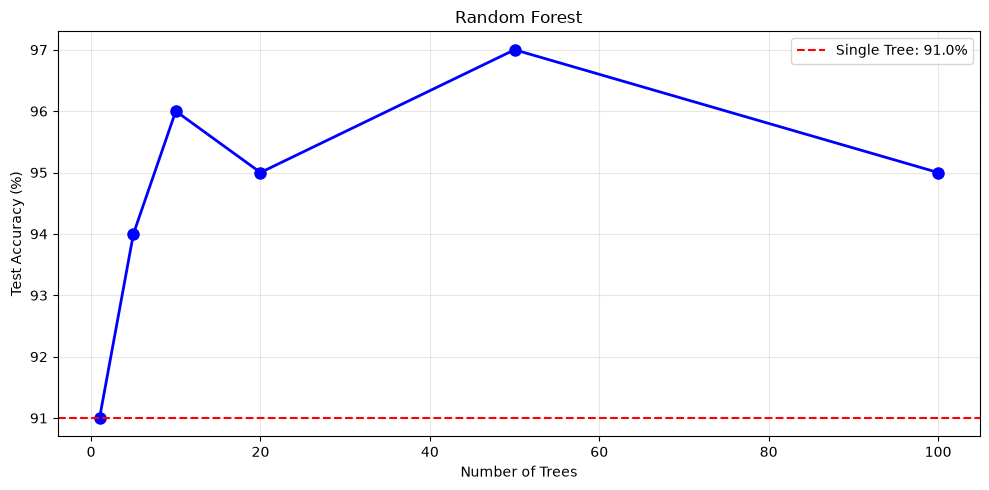

In [35]:
tree_counts = [1, 5, 10, 20, 50, 100]
accuracies = []

for n in tree_counts:
    rf = RandomForestScratch(n_trees=n, max_depth=5)
    rf.fit(X_train, y_train)
    acc = rf.score(X_test, y_test) * 100
    accuracies.append(acc)
    print(f"Trees: {n:>3d} | Accuracy: {acc:.1f}%")

plt.figure(figsize=(10, 5))
plt.plot(tree_counts, accuracies, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=sg_acc, color='r', linestyle='--', label=f'Single Tree: {sg_acc:.1f}%')
plt.xlabel('Number of Trees')
plt.ylabel('Test Accuracy (%)')
plt.title('Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('random_forest_trees.png', dpi=150, bbox_inches='tight')
plt.show()
    

In [36]:
from pprint import pprint

# Printing the nested dict structure directly
pprint(sg_tre.root)

{'feature': 6,
 'leaf': False,
 'left': {'feature': 8,
          'leaf': False,
          'left': {'feature': 3,
                   'leaf': False,
                   'left': {'leaf': True, 'value': np.int64(1)},
                   'right': {'feature': 0,
                             'leaf': False,
                             'left': {'leaf': True, 'value': np.int64(0)},
                             'right': {'feature': 0,
                                       'leaf': False,
                                       'left': {'leaf': True,
                                                'value': np.int64(1)},
                                       'right': {'leaf': True,
                                                 'value': np.int64(0)},
                                       'threshold': np.float64(5.887939742282698)},
                             'threshold': np.float64(4.8964490404694505)},
                   'threshold': np.float64(0.491860467003709)},
          'right': {'feature


# COMPARING WITH SCIKIT-LEARN


In [41]:
sklearn_rf = SklearnRF(n_estimators=50, max_depth=5, random_state=42)
sklearn_rf.fit(X_train, y_train)

print(f"{'Metric':<20} {'From Scratch':>15} {'Scikit-Learn':>15}")
print(f"{'-'*50}")
print(f"{'Train Accuracy':<20} {forest.score(X_train, y_train)*100:>14.1f}% {sklearn_rf.score(X_train, y_train)*100:>14.1f}%")
print(f"{'Test Accuracy':<20} {forest.score(X_test, y_test)*100:>14.1f}% {sklearn_rf.score(X_test, y_test)*100:>14.1f}%")

# Feature importance (from sklearn for comparison)
print(f"\nTop 5 features (sklearn):")
importance = sklearn_rf.feature_importances_
for idx in np.argsort(importance)[::-1][:5]:
    print(f"  Feature {idx}: {importance[idx]:.3f}")

Metric                  From Scratch    Scikit-Learn
--------------------------------------------------
Train Accuracy                100.0%          100.0%
Test Accuracy                  95.0%           96.0%

Top 5 features (sklearn):
  Feature 6: 0.261
  Feature 8: 0.248
  Feature 7: 0.145
  Feature 9: 0.139
  Feature 3: 0.101


### Key Takeaways & Interpretation

* **Successful Implementation:** The custom `RandomForestScratch` model performs virtually identically to Scikit-Learn's standard `RandomForestClassifier` (**95.0%** vs **96.0%** test accuracy). This confirms my bootstrap sampling, feature randomness, and voting logic are implemented correctly.
* **Effective Generalization:** Both models achieve 100% training accuracy while maintaining strong performance on the test set (~95–96%), demonstrating that ensembling successfully controls overfitting.
* **Feature Importance:** **Feature 6** (~26.1%) and **Feature 8** (~24.8%) are the most critical predictors, driving over 50% of the overall decision-making across the forest.


### What was built:
  - SimpleDecisionTree with max_features (random subsets)
  - RandomForestScratch using bootstrap + voting
  - fit(), predict(), score() methods

### Key concepts:
  - Bagging: train on bootstrap samples (random with replacement)
  - Feature randomness: each split only considers sqrt(n) features
  - Voting: majority vote across all trees
  - More trees = better accuracy (diminishing returns after ~50)
  - This is the foundation for XGBoost and LightGBM

Verified against scikit-learn: comparable results.